## 函式庫與資料集載入

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os.path

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

from tensorflow.keras.datasets import cifar10

In [2]:
# 指定亂數種子
seed = 7
np.random.seed(seed)

In [3]:
# 載入 Cifar10 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 500s 3us/step


/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
# 形狀
print("X_train.shape: ", X_train.shape)
print("Y_train.shape: ", Y_train.shape)
print("X_test.shape: ", X_test.shape)
print("Y_test.shape: ", Y_test.shape)

X_train.shape:  (50000, 32, 32, 3)
Y_train.shape:  (50000, 1)
X_test.shape:  (10000, 32, 32, 3)
Y_test.shape:  (10000, 1)


In [5]:
# 顯示 Numpy 二維陣列內容
print(X_train[0])
print(Y_train[0])   # 標籤資料

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


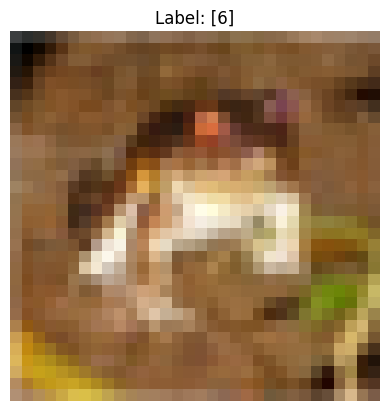

In [6]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.title("Label: " + str(Y_train[0]))
plt.axis("off")
# 顯示圖片
plt.show()

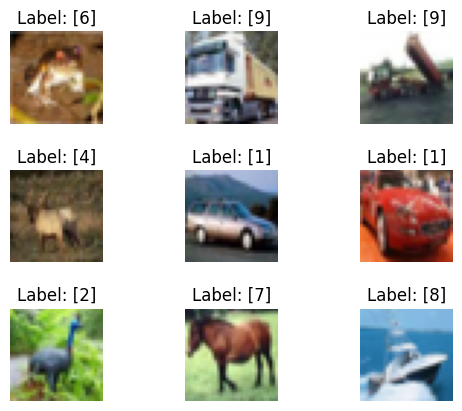

In [7]:
# 繪出9張圖片
sub_plot= 330
for i in range(0, 9):
    ax = plt.subplot(sub_plot+i+1)
    ax.imshow(X_train[i], cmap="binary")
    ax.set_title("Label: " + str(Y_train[i]))
    ax.axis("off")

plt.subplots_adjust(hspace = .5)
# 顯示數字圖片
plt.show()

## 圖檔前處理

In [8]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

## 訓練CNN模型

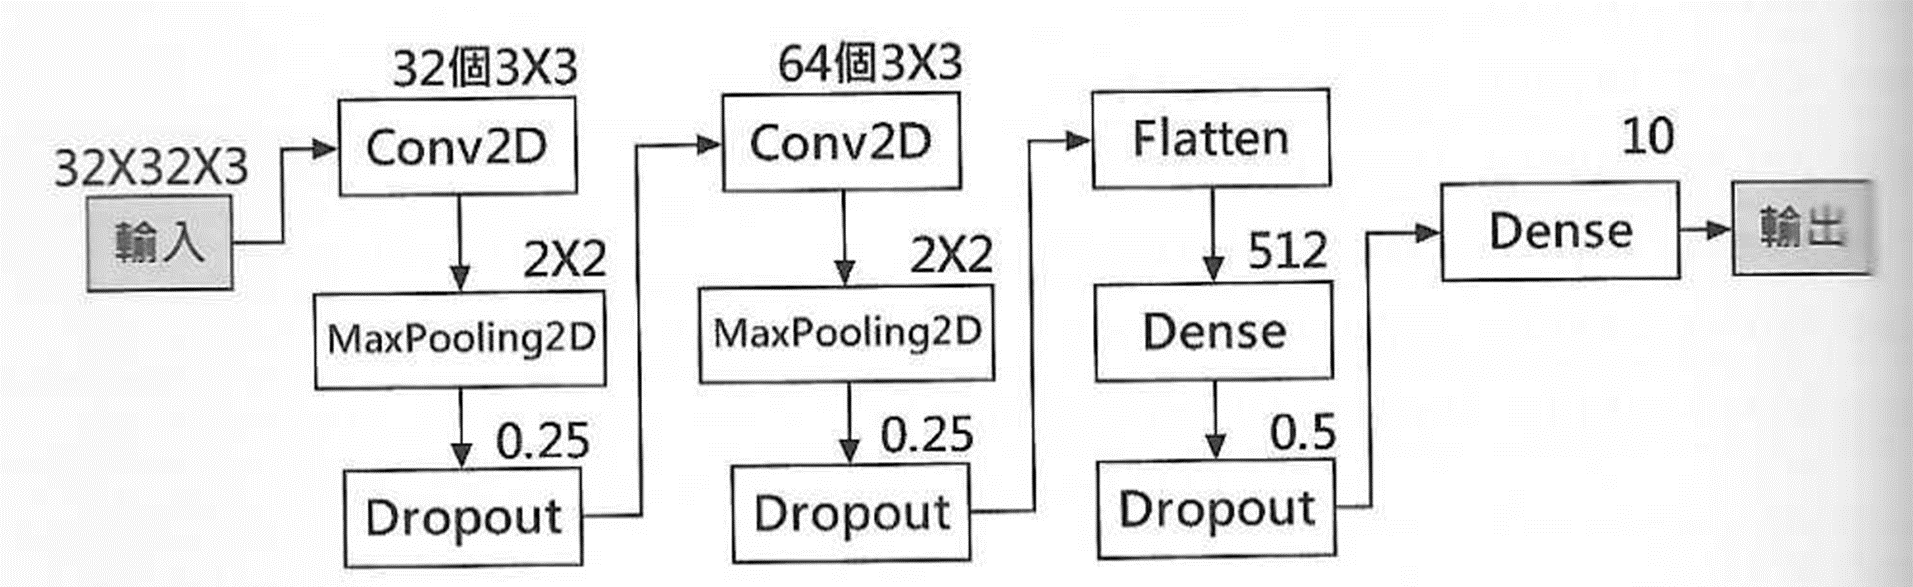

In [9]:
# 定義模型 (如果有已經訓練過的模型權重檔cifar10.h5，則載入之)
if (os.path.exists('cifar101.h5')):
  model = load_model('cifar10.h5')
  print("已載入模型架構與權重檔")
else:
  model = Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), padding="same", input_shape=X_train.shape[1:], activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))
  model.add(Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))
  model.add(Flatten())
  model.add(Dense(512, activation="relu"))
  model.add(Dropout(0.5))
  model.add(Dense(10, activation="softmax"))
  model.summary()   # 顯示模型摘要資訊

/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,186 (8.10 MB)

 Trainable params: 2,122,186 (8.10 MB)

 Non-trainable params: 0 (0.00 B)

*   3×(3×3)×32＋32 ＝ 896
*   32×(3×3)×64＋64 ＝ 18496
*   4096×512＋512 ＝ 2097664
*   512×10＋10 ＝ 5130

In [10]:
# 編譯模型
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [11]:
# 訓練模型
history = model.fit(X_train, Y_train, validation_split=0.2, epochs=10, batch_size=128, verbose=2)

Epoch 1/10
313/313 - 54s - 173ms/step - accuracy: 0.3977 - loss: 1.6530 - val_accuracy: 0.5259 - val_loss: 1.3573
Epoch 2/10
313/313 - 45s - 144ms/step - accuracy: 0.5367 - loss: 1.2981 - val_accuracy: 0.6031 - val_loss: 1.1382
Epoch 3/10
313/313 - 45s - 143ms/step - accuracy: 0.5896 - loss: 1.1495 - val_accuracy: 0.6414 - val_loss: 1.0290
Epoch 4/10
313/313 - 40s - 127ms/step - accuracy: 0.6237 - loss: 1.0611 - val_accuracy: 0.6644 - val_loss: 0.9738
Epoch 5/10
313/313 - 49s - 158ms/step - accuracy: 0.6500 - loss: 0.9854 - val_accuracy: 0.6778 - val_loss: 0.9273
Epoch 6/10
313/313 - 41s - 132ms/step - accuracy: 0.6682 - loss: 0.9413 - val_accuracy: 0.6864 - val_loss: 0.9021
Epoch 7/10
313/313 - 34s - 110ms/step - accuracy: 0.6854 - loss: 0.8939 - val_accuracy: 0.6953 - val_loss: 0.8990
Epoch 8/10
313/313 - 36s - 114ms/step - accuracy: 0.6982 - loss: 0.8542 - val_accuracy: 0.7081 - val_loss: 0.8476
Epoch 9/10
313/313 - 36s - 116ms/step - accuracy: 0.7153 - loss: 0.8092 - val_accuracy: 

In [12]:
# 評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
print("訓練資料集的準確度 = {:.4f}".format(accuracy))
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print("測試資料集的準確度 = {:.4f}".format(accuracy))


Testing ...
訓練資料集的準確度 = 0.8008
測試資料集的準確度 = 0.7241


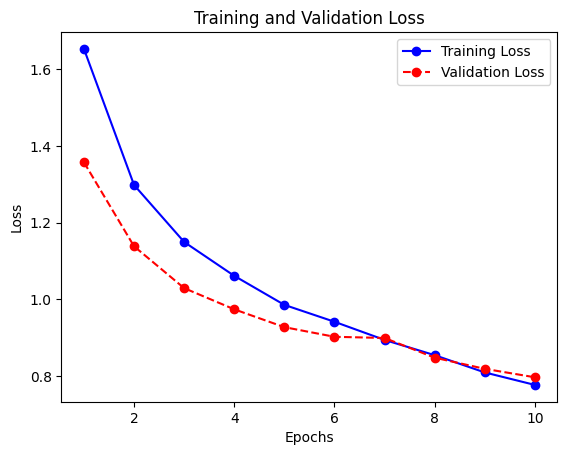

In [13]:
# 顯示圖表來分析模型的訓練過程
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

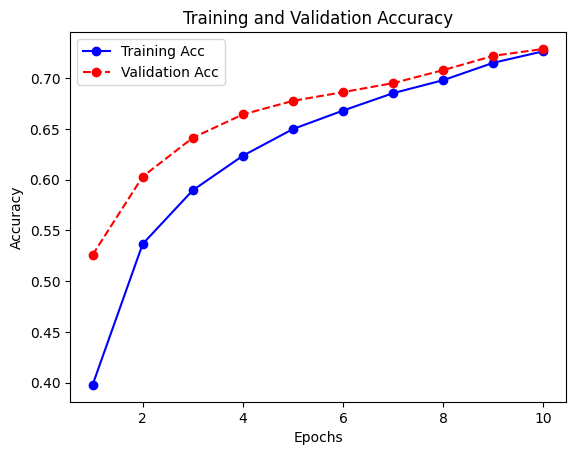

In [14]:
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo-", label="Training Acc")
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
# 計算分類的預測值
print("\nPredicting ...")
Y_pred = model.predict(X_test)
Y_pred_classes=np.argmax(Y_pred,axis=1)

# 顯示混淆矩陣
tb = pd.crosstab(Y_test_bk.astype(int).flatten(), Y_pred_classes.astype(int), rownames=["label"], colnames=["predict"])
print(tb)


Predicting ...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
predict    0    1    2    3    4    5    6    7    8    9
label                                                    
0        796   11   40   17   10    9    8   13   69   27
1         26  824    5    9    2    9    8    5   30   82
2         72    4  569   52   97  102   49   35   12    8
3         31    9   67  447   58  279   43   35   18   13
4         38    2   57   55  687   47   26   76   12    0
5         18    3   41  108   29  736    9   43    9    4
6          6    6   39   65   51   57  754    8    9    5
7         13    1   36   24   35   78    1  801    5    6
8         67   27    7    8    7   11    3    4  854   12
9         40   82   14   14    2   15    4   17   39  773


In [16]:
# 儲存Keras模型
print("Saving Model: 413570012_20260508.keras ...")
model.save("413570012_20260508.keras")

Saving Model: 413570012_20260508.keras ...


## 模型推論，辨識照片是十種分類中的哪一類

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


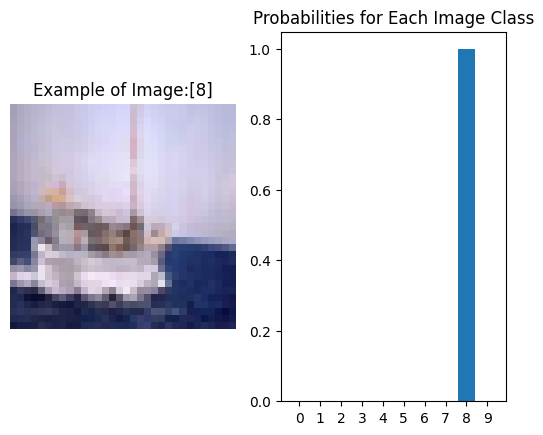

In [17]:
# 隨機選一張測試的圖片 
i = np.random.randint(0, len(X_test))
img = X_test[i]
# 將圖片轉換成 4D 張量
X_test_img = img.reshape(1, 32, 32, 3).astype("float32")
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model("413570012_20260508.keras")
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# 模型對圖片進行辨識
Y_pred_probs = model_inference.predict(X_test_img)

# 繪出圖片與其分類答案
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Image:" + str(Y_test_bk[i]))
plt.imshow(img, cmap="binary")
plt.axis("off")

# 預測結果的機率
plt.subplot(1,2,2)
plt.title("Probabilities for Each Image Class")
plt.bar(np.arange(10), Y_pred_probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

## 檢查辨識錯誤的圖檔

In [18]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

Y_test_fl = Y_test_bk.flatten() # 標準答案的資料格式轉換成一維

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


In [19]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_fl, "predict":Y_pred_classes})
df = df[Y_test_fl!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤

    label  predict
22      4        2
24      5        4
25      2        4
32      4        2
33      5        3


In [20]:
len(df)

2759

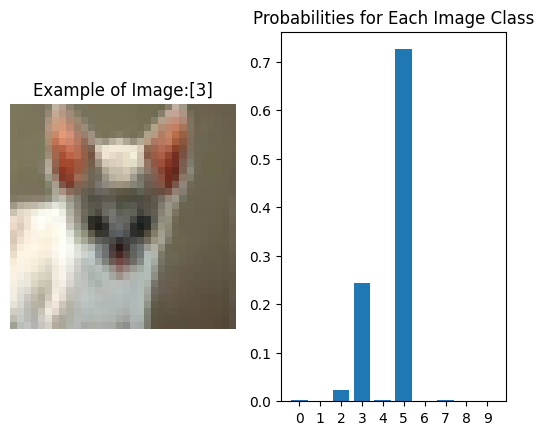

In [21]:
# 隨機選1個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
img = X_test[i]

# 繪出圖片與其分類答案
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Image:" + str(Y_test_bk[i]))
plt.imshow(img, cmap="binary")
plt.axis("off")

# 預測結果的機率
plt.subplot(1,2,2)
plt.title("Probabilities for Each Image Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

In [22]:
# 預測錯誤的筆數
len(df)

2759

In [23]:
# 作業計算公式
base = 2830
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)

80.5017667844523
